#MOTS PROJECT ------ "use table of contents to help navigate"

Note: some of the code is commented out as we dont always want to run training steps

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Preprocessing/Setup

## Setup Environment

Installs ------ "only run this once"

In [ ]:
!pip install -q gdown
!pip install -q albumentations==1.3.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.7/125.7 kB 13.0 MB/s eta 0:00:00


Imports

In [ ]:
import gdown
import zipfile
import os
from torch.utils.data import DataLoader
import random
import numpy as np
from tqdm import tqdm
import torch
import pandas as pd
import matplotlib.patches as patches
import torchvision
from torch.utils.data import Dataset
from PIL import Image
import matplotlib.pyplot as plt
import torchvision.transforms.functional as TF
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
import torch.nn as nn
import torchvision.models as models
from collections import deque
from torchvision.models.resnet import resnet50
from torchvision.transforms import functional as F
from scipy.spatial.distance import cosine
from scipy.optimize import linear_sum_assignment
import torchvision.transforms as T
import torch.nn.functional as F
import cv2
from torchvision.models import resnet50, ResNet50_Weights


Grab Data  ------  "After runing this you should be able to see the data under files. note: I am using google colab to run this!"

In [ ]:
#Im using a link that should be public on my google drive so this code should run just fine for anyone!

file_id = '1PyNizLJ8JvQPha7FzGeoj7eYXsoozrYi'
url = f'https://drive.google.com/uc?id={file_id}'
output = 'MOT16.zip'

gdown.download(url, output, quiet=False)
extract_path = './MOT16'
os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile('MOT16.zip', 'r') as zip_ref:
    zip_ref.extractall(extract_path)

Downloading...
From (original): https://drive.google.com/uc?id=1PyNizLJ8JvQPha7FzGeoj7eYXsoozrYi
From (redirected): https://drive.google.com/uc?id=1PyNizLJ8JvQPha7FzGeoj7eYXsoozrYi&confirm=t&uuid=fafd3e45-a300-464b-9216-dd57447dfbcd
To: /content/MOT16.zip
100%|██████████| 1.95G/1.95G [00:37<00:00, 52.7MB/s]


file structure should look something like this, you can find the files on the left side of google colab under the key icon
```
/MOT16/
  ├── test/
  │   ├── MOT16-01/
  │   └── MOT16-02/
  ├── train/
  └── ...
```

Random Seeding

In [ ]:
#Setting a seed for the environment
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # For deterministic behavior (at the cost of some speed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

#seed PyTorch
set_seed(19990519)

In [ ]:
# 🔧 Change this to use a different MOT16 sequence
Vsequence = 'MOT16-04'

# Auto-resolve paths based on sequence
img_dir = f'./MOT16/train/{Vsequence}/img1'
gt_path = f'./MOT16/train/{Vsequence}/gt/gt.txt'


##DataLoading / Handling

Dataset Class for data handling - We do this before data augmentation so our bounding boxes stay consistant 'ie. when an image is flipped'

In [ ]:
class MOT16Dataset(Dataset):
    def __init__(self, root_dir, sequence=Vsequence, transforms=None): #set folder paths/store transformations etc
        self.sequence_path = os.path.join(root_dir, sequence)
        self.img_dir = os.path.join(self.sequence_path, 'img1') #under each video the images are stored in the folder img1
        self.gt_path = os.path.join(self.sequence_path, 'gt', 'gt.txt') #gt.txt contains the ground truth information
        self.transforms = transforms

        # Load ground truth as a dataframe
        cols = ['frame', 'id', 'bb_left', 'bb_top', 'bb_width', 'bb_height', 'conf', 'class', 'visibility']
        self.gt_df = pd.read_csv(self.gt_path, header=None, names=cols)

        # Keep only visible, valid boxes (optional) (removes ignored objects) & (adjust visibility to filter out low visibility objects)
        self.gt_df = self.gt_df[(self.gt_df['id'] != -1) & (self.gt_df['class'] == 1) & (self.gt_df['visibility'] > 0.3)]

        # Build frame to annotations map (groups the annotations by frame number & stores frames in order)
        self.frame_dict = dict(tuple(self.gt_df.groupby('frame')))
        self.frame_numbers = sorted(self.frame_dict.keys())

    #Returns the number of frames in the dataset
    def __len__(self):
        return len(self.frame_numbers)

    #Called when you do dataset[i].loads (the i-th frame's image & bounding boxes in that frame)
    def __getitem__(self, idx):
        frame_num = self.frame_numbers[idx]
        img_path = os.path.join(self.img_dir, f"{frame_num:06d}.jpg")
        image = Image.open(img_path).convert("RGB")

        annotations = self.frame_dict[frame_num]

        boxes = annotations[['bb_left', 'bb_top', 'bb_width', 'bb_height']].values
        boxes = [[float(x), float(y), float(x + w_), float(y + h_)] for x, y, w_, h_ in boxes]
        # 🩹 Clamp boxes to image bounds
        w, h = image.size
        boxes = [[
            max(0, min(x1, w)),
            max(0, min(y1, h)),
            max(0, min(x2, w)),
            max(0, min(y2, h))
        ] for x1, y1, x2, y2 in boxes]

        labels = [1] * len(boxes)

        # DO NOT CONVERT TO TORCH HERE — just pass image as NumPy array and boxes as list of lists
        if self.transforms:
            transformed = self.transforms(
                image=np.array(image),
                bboxes=boxes,
                labels=labels
            )
            print("Transformed box:", transformed['bboxes'][0])
            image = transformed['image']                     # Tensor now
            boxes = transformed['bboxes']                    # List of lists
            labels = transformed['labels']                   # List



        # Convert to tensors here
        boxes = torch.tensor(boxes, dtype=torch.float32)
        labels = torch.tensor(labels, dtype=torch.int64)

        # Filter invalid boxes
        valid_mask = (
            (boxes[:, 0] >= 0) & (boxes[:, 1] >= 0) &
            (boxes[:, 2] > boxes[:, 0]) & (boxes[:, 3] > boxes[:, 1])
        )
        boxes = boxes[valid_mask]
        labels = labels[valid_mask]

        target = {
            'boxes': boxes,
            'labels': labels,
            'image_id': torch.tensor([frame_num])
        }

        return image, target





function for showing an image

In [ ]:
dataset = MOT16Dataset(
    root_dir='./MOT16/train',  # This works in Colab
    sequence=Vsequence,
    transforms=None  # or some transform function
)

dataloader = DataLoader(
    dataset,
    batch_size=4,
    shuffle=True,
    collate_fn=lambda x: tuple(zip(*x))  # simple collate fn for now
)


In [ ]:
def show_image_with_boxes(image_input, boxes, figsize=(12, 8)):
    # Convert to NumPy array if needed
    if isinstance(image_input, torch.Tensor):
        image = image_input.permute(1, 2, 0).cpu().numpy()
        # Undo normalization if needed
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        image = (image * std + mean).clip(0, 1)
    elif isinstance(image_input, Image.Image):
        image = np.array(image_input) / 255.0  # scale to [0, 1]
    else:
        raise TypeError(f"Unsupported image type: {type(image_input)}")

    fig, ax = plt.subplots(1, figsize=figsize)
    ax.imshow(image)

    for box in boxes:
        x1, y1, x2, y2 = box.tolist()
        width, height = x2 - x1, y2 - y1
        rect = patches.Rectangle((x1, y1), width, height,
                                 linewidth=2, edgecolor='red', facecolor='none')
        ax.add_patch(rect)

    plt.axis('off')
    plt.show()

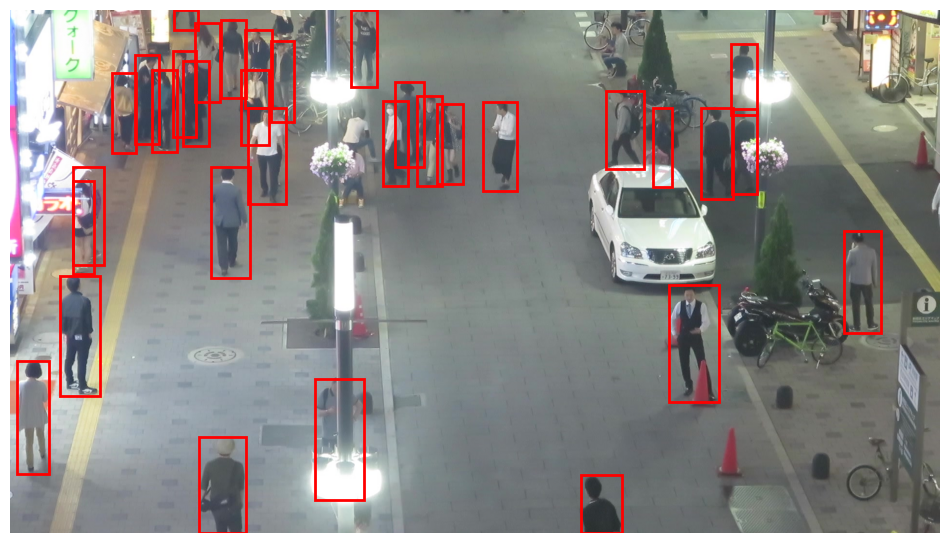

In [ ]:
image, target = dataset[80]
boxes = target['boxes']

show_image_with_boxes(image, boxes)

some possible bad annotations seen earlier that are being filtered out fyi!

##Data Augmentation

We can add more later but im starting with just using albumentations

### Albumentations

Albumentations for training should give you both unaugmented and augmented data, randomly, during training.

In [ ]:
def get_train_transforms():
    return A.Compose([
        A.HorizontalFlip(p=0.5),
        A.RandomBrightnessContrast(p=0.2),
        A.Resize(512, 512),  # Albumentations will handle resizing of bboxes too
        A.Normalize(mean=(0.485, 0.456, 0.406),
                    std=(0.229, 0.224, 0.225)),
        ToTensorV2()
    ], bbox_params=A.BboxParams(
        format='pascal_voc',       #  MUST be pascal_voc (absolute pixel)
        label_fields=['labels'],
        min_visibility=0.3         # Optional, avoids invisible boxes
    ))


In [ ]:
transforms = get_train_transforms()
dataset = MOT16Dataset(root_dir='./MOT16/train', sequence=Vsequence, transforms=transforms)

In [ ]:
print("Image shape:", image.size)
print("Sample box:", boxes[0])


Image shape: (1920, 1080)
Sample box: tensor([1363.,  569., 1466.,  810.])


Transformed box: (np.float64(363.46666666666664), np.float64(269.7481481481482), np.float64(390.93333333333334), np.float64(384.0))


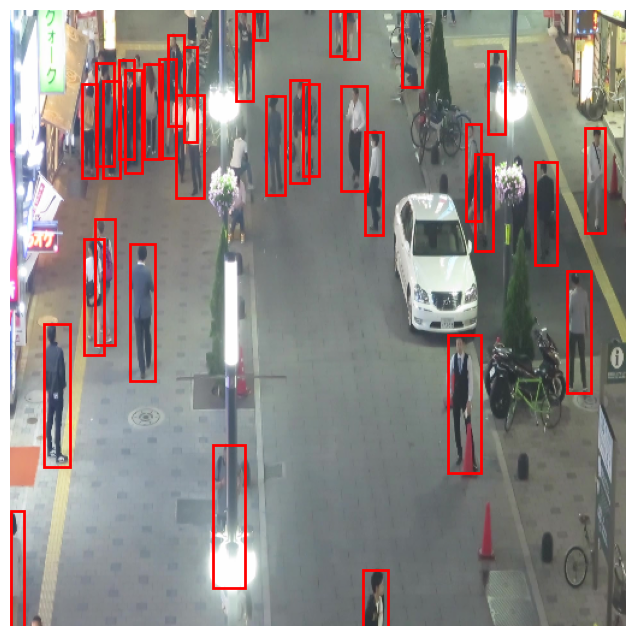

In [ ]:
image, target = dataset[0]
boxes = target['boxes']
show_image_with_boxes(image, boxes)

In [ ]:
def collate_fn(batch):
    return tuple(zip(*batch))

train_dataset = MOT16Dataset(
    root_dir='./MOT16/train',
    sequence=Vsequence, #this line here determines what video is used
    transforms=get_train_transforms()
)

train_loader = DataLoader(
    train_dataset,
    batch_size=2,
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=0  # Set >0 if using locally
)

#Faster R-CNN Model

In [ ]:
#placeholder code
def get_frcnn_model(num_classes=2):
    model = torchvision.models.detection.fasterrcnn_resnet50_fpn(pretrained=True)

    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

    return model


In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = get_frcnn_model(num_classes=2)
model.to(device)


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(

In [ ]:
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=0.001, momentum=0.9, weight_decay=0.0005)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

##Load R-CNN PretrainedModel

Note: update this before submission to be able to load from google drive with final model

In [ ]:
!pip install gdown


In [ ]:
import gdown

# Google Drive file ID from your link:
# https://drive.google.com/file/d/1Yu09zketToPWm_XcUlEY11fjAt7KpQHP/view?usp=sharing
file_id = "1Yu09zketToPWm_XcUlEY11fjAt7KpQHP"
output = "frcnn.pth"

# Download the file
gdown.download(f"https://drive.google.com/uc?id={file_id}", output, quiet=False)


Downloading...
From (original): https://drive.google.com/uc?id=1Yu09zketToPWm_XcUlEY11fjAt7KpQHP
From (redirected): https://drive.google.com/uc?id=1Yu09zketToPWm_XcUlEY11fjAt7KpQHP&confirm=t&uuid=07ef0045-dae8-4576-9cf4-26d0615e074b
To: /content/frcnn.pth
100%|██████████| 166M/166M [00:01<00:00, 135MB/s]


'frcnn.pth'

In [ ]:
model = get_frcnn_model(num_classes=2)  # must match original architecture
model.load_state_dict(torch.load("frcnn.pth"))
model.to(device)
model.eval()  # very important for inference

FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(

##Train R-CNN

Note: Comment out when not training

In [ ]:
'''
num_epochs = 20

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0

    for images, targets in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        epoch_loss += losses.item()
        print(f"Batch loss: {losses.item():.4f}")

    torch.save(model.state_dict(), f'frcnn_epoch{epoch+1}.pth')
    print(f"Epoch {epoch+1} Loss: {epoch_loss:.4f}")
    lr_scheduler.step()
'''

'\nnum_epochs = 20\n\nfor epoch in range(num_epochs):\n    model.train()\n    epoch_loss = 0\n\n    for images, targets in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):\n        images = [img.to(device) for img in images]\n        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]\n\n        loss_dict = model(images, targets)\n        losses = sum(loss for loss in loss_dict.values())\n\n        optimizer.zero_grad()\n        losses.backward()\n        optimizer.step()\n\n        epoch_loss += losses.item()\n        print(f"Batch loss: {losses.item():.4f}")\n\n    torch.save(model.state_dict(), f\'frcnn_epoch{epoch+1}.pth\')\n    print(f"Epoch {epoch+1} Loss: {epoch_loss:.4f}")\n    lr_scheduler.step()\n'

In [ ]:
def show_image_with_boxes(image_tensor, boxes, scores=None, threshold=0.5):
    image = image_tensor.permute(1, 2, 0).cpu().numpy()
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    image = (image * std + mean).clip(0, 1)

    fig, ax = plt.subplots(1, figsize=(12, 8))
    ax.imshow(image)

    for i, box in enumerate(boxes):
        x1, y1, x2, y2 = box.tolist()
        width, height = x2 - x1, y2 - y1
        rect = patches.Rectangle((x1, y1), width, height,
                                 linewidth=2, edgecolor='lime', facecolor='none')
        ax.add_patch(rect)

        if scores is not None and scores[i] > threshold:
            ax.text(x1, y1 - 2, f'{scores[i]:.2f}', color='lime', fontsize=10)

    plt.axis('off')
    plt.show()


Transformed box: (np.float64(121.86666666666667), np.float64(269.27407407407406), np.float64(149.33333333333331), np.float64(383.52592592592595))


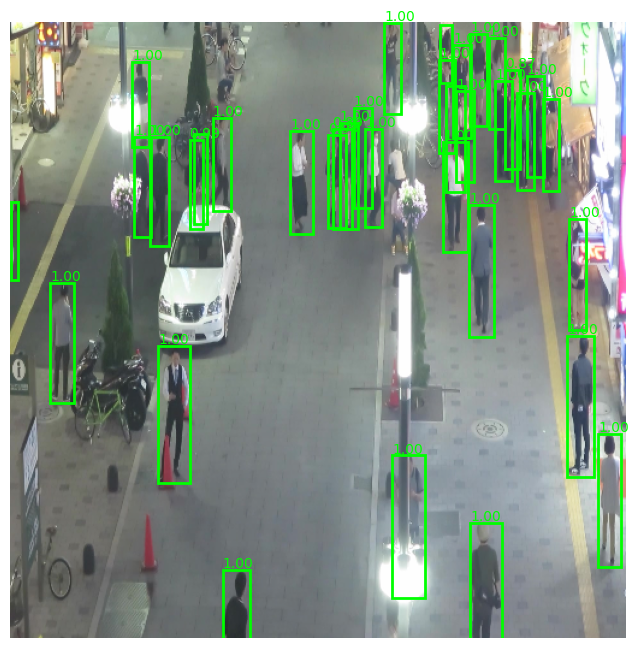

In [ ]:
model.eval()
image, _ = dataset[82]  # any sample frame
input_tensor = image.unsqueeze(0).to(device)

with torch.no_grad():
    prediction = model(input_tensor)

boxes = prediction[0]['boxes'].cpu()
scores = prediction[0]['scores'].cpu()

show_image_with_boxes(image, boxes, scores, threshold=0.5)


In [ ]:
print(scores)

tensor([0.9999, 0.9998, 0.9998, 0.9997, 0.9997, 0.9997, 0.9997, 0.9997, 0.9996,
        0.9996, 0.9996, 0.9996, 0.9996, 0.9995, 0.9995, 0.9995, 0.9994, 0.9994,
        0.9993, 0.9993, 0.9993, 0.9986, 0.9984, 0.9982, 0.9975, 0.9963, 0.9962,
        0.9954, 0.9895, 0.9893, 0.8855, 0.8685, 0.2536, 0.1578, 0.1085, 0.0687])


#Siamese ReID Model

In [ ]:
class SiameseReID(nn.Module):
    def __init__(self, embedding_dim=128, pretrained=True):
        super(SiameseReID, self).__init__()
        base_model = resnet50(weights=ResNet50_Weights.DEFAULT if pretrained else None)
        self.features = nn.Sequential(*list(base_model.children())[:-1])
        self.embedding = nn.Sequential(
            nn.Linear(2048, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(512, embedding_dim),
            nn.BatchNorm1d(embedding_dim)
        )

    def forward_once(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.embedding(x)
        x = F.normalize(x, p=2, dim=1)  # Normalize to unit length
        return x

    def forward(self, img1, img2):
        return self.forward_once(img1), self.forward_once(img2)

class Track:
    def __init__(self, detection, track_id, n_init, max_age, feature=None):
        self.track_id = track_id
        self.hits = 1
        self.age = 1
        self.time_since_update = 0
        self.state = detection
        self.history = []
        self.features = deque([feature], maxlen=100) if feature is not None else deque(maxlen=100)
        self._n_init = n_init
        self._max_age = max_age
        self.state_history = deque(maxlen=30)
        self.state_history.append(detection)

    def predict(self):
        self.age += 1
        self.time_since_update += 1

    def update(self, detection, feature=None):
        self.state = detection
        self.hits += 1
        self.time_since_update = 0
        self.state_history.append(detection)
        if feature is not None:
            self.features.append(feature)

    def mark_missed(self):
        self.time_since_update += 1

    def is_tentative(self):
        return self.hits < self._n_init

    def is_confirmed(self):
        return self.hits >= self._n_init

    def is_deleted(self):
        return self.time_since_update > self._max_age

class DeepSORT:
    def __init__(self, max_age=30, n_init=3, nn_budget=100, max_cosine_distance=0.2):
        self.max_age = max_age
        self.n_init = n_init
        self.nn_budget = nn_budget
        self.max_cosine_distance = max_cosine_distance
        self.tracks = []
        self._next_id = 1
        self.reid_model = SiameseReID(pretrained=True)
        self.reid_model.eval()

    def update(self, detections):
        # Extract features for all detections
        features = self._get_features(detections)

        # Predict new locations for existing tracks
        for track in self.tracks:
            track.predict()

        # Match detections to tracks
        matches, unmatched_tracks, unmatched_detections = self._match(detections, features)

        # Update matched tracks
        for track_idx, detection_idx in matches:
            self.tracks[track_idx].update(detections[detection_idx], features[detection_idx])

        # Create new tracks for unmatched detections
        for detection_idx in unmatched_detections:
            self._initiate_track(detections[detection_idx], features[detection_idx])

        # Remove dead tracks
        self.tracks = [t for t in self.tracks if not t.is_deleted()]

        return self.tracks

    def _get_features(self, detections):
        features = []
        for det in detections:
            x1, y1, x2, y2, image = det  # assuming detection = (bbox + frame)
            crop = image[int(y1):int(y2), int(x1):int(x2)]
            crop = cv2.resize(crop, (128, 256))  # resize for ReID
            crop = self._preprocess(crop)
            with torch.no_grad():
                emb = self.reid_model.forward_once(crop.to(self.device)).cpu().numpy()
            features.append(emb.flatten())
        return np.array(features)


    def _match(self, detections, features):
        if len(self.tracks) == 0:
            return [], [], list(range(len(detections)))

        # Compute cost matrix
        cost_matrix = self._compute_cost_matrix(detections, features)

        # Solve the assignment problem
        row_indices, col_indices = linear_sum_assignment(cost_matrix)

        # Filter out matches with too high cost
        matches = []
        for row, col in zip(row_indices, col_indices):
            if cost_matrix[row, col] > self.max_cosine_distance:
                continue
            matches.append((row, col))

        # Find unmatched tracks and detections
        unmatched_tracks = [t for t in range(len(self.tracks))
                          if t not in [match[0] for match in matches]]
        unmatched_detections = [d for d in range(len(detections))
                              if d not in [match[1] for match in matches]]

        return matches, unmatched_tracks, unmatched_detections

    def _compute_cost_matrix(self, detections, features):
        # Compute appearance cost
        appearance_cost = np.zeros((len(self.tracks), len(detections)))
        for i, track in enumerate(self.tracks):
            for j, feature in enumerate(features):
                if len(track.features) > 0:
                    # Use the most recent feature for matching
                    appearance_cost[i, j] = min(
                        [cosine(track_feat, feature) for track_feat in track.features]
                    )
                else:
                    appearance_cost[i, j] = 1.0  # Max distance if no features

        return appearance_cost

    def _initiate_track(self, detection, feature):
        self.tracks.append(Track(detection, self._next_id, self.n_init, self.max_age, feature))
        self._next_id += 1

In [ ]:
'''class ContrastiveLoss(nn.Module):
    def __init__(self, margin=0.9):
        super(ContrastiveLoss, self).__init__()
        self.margin = margin

    def forward(self, output1, output2, label):
        # Euclidean distance
        distance = torch.nn.functional.pairwise_distance(output1, output2)

        # Loss for similar (label == 1) and dissimilar (label == 0) pairs
        loss = (label) * torch.pow(distance, 2) + \
               (1 - label) * torch.pow(torch.clamp(self.margin - distance, min=0.0), 2)
        return loss.mean()'''

'class ContrastiveLoss(nn.Module):\n    def __init__(self, margin=0.9):\n        super(ContrastiveLoss, self).__init__()\n        self.margin = margin\n\n    def forward(self, output1, output2, label):\n        # Euclidean distance\n        distance = torch.nn.functional.pairwise_distance(output1, output2)\n\n        # Loss for similar (label == 1) and dissimilar (label == 0) pairs\n        loss = (label) * torch.pow(distance, 2) +                (1 - label) * torch.pow(torch.clamp(self.margin - distance, min=0.0), 2)\n        return loss.mean()'

In [ ]:
'''device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = SiameseReID().to(device)
criterion = ContrastiveLoss(margin=1.0)
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)


NameError: name 'ContrastiveLoss' is not defined

In [ ]:
import os
import cv2
import pandas as pd
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor

# --- Config ---
mot_root = './MOT16/train'
output_dir = './reid_dataset'
sequences = ['MOT16-02', 'MOT16-04', 'MOT16-05', 'MOT16-09', 'MOT16-10', 'MOT16-11']
os.makedirs(output_dir, exist_ok=True)

def process_row(row, img_dir, seq):
    frame_num = int(row.frame)
    person_id = int(row.id)

    img_path = os.path.join(img_dir, f"{frame_num:06d}.jpg")
    if not os.path.exists(img_path):
        return

    image = cv2.imread(img_path)
    if image is None:
        return

    h, w, _ = image.shape
    x1, y1 = int(row.bb_left), int(row.bb_top)
    x2 = x1 + int(row.bb_width)
    y2 = y1 + int(row.bb_height)

    # ✅ Validate coordinates
    x1, y1 = max(0, x1), max(0, y1)
    x2, y2 = min(w, x2), min(h, y2)
    if x2 <= x1 or y2 <= y1:
        return  # Invalid crop, skip

    crop = image[y1:y2, x1:x2]

    if crop.size == 0:
        return  # Also skip if crop is still empty for any reason

    id_folder = os.path.join(output_dir, f"{person_id:04d}")
    os.makedirs(id_folder, exist_ok=True)

    save_path = os.path.join(id_folder, f"{seq}_frame{frame_num:06d}.jpg")
    cv2.imwrite(save_path, crop)



# --- Process Sequences ---
for seq in sequences:
    print(f"📂 Processing sequence: {seq}")
    img_dir = os.path.join(mot_root, seq, 'img1')
    gt_path = os.path.join(mot_root, seq, 'gt', 'gt.txt')

    gt = pd.read_csv(gt_path, header=None)
    gt.columns = ['frame', 'id', 'bb_left', 'bb_top', 'bb_width', 'bb_height',
                  'conf', 'class', 'visibility']

    gt = gt[(gt['class'] == 1) & (gt['visibility'] > 0.3)]
    rows = list(gt.itertuples(index=False))

    #  Parallel cropping
    with ThreadPoolExecutor(max_workers=4) as executor:
        list(tqdm(executor.map(lambda row: process_row(row, img_dir, seq), rows), total=len(rows)))

print("✅ Finished cropping all sequences!")


📂 Processing sequence: MOT16-02


100%|██████████| 8833/8833 [00:19<00:00, 442.70it/s]


📂 Processing sequence: MOT16-04


100%|██████████| 36265/36265 [01:32<00:00, 391.33it/s]


📂 Processing sequence: MOT16-05


...

📂 Processing sequence: MOT16-10


100%|██████████| 9944/9944 [00:20<00:00, 483.62it/s]


📂 Processing sequence: MOT16-11


100%|██████████| 7095/7095 [00:15<00:00, 447.11it/s]

✅ Finished cropping all sequences!


In [ ]:
class ReIDDataset(Dataset):
    def __init__(self, root_dir, transform=None, verbose=False):
        self.root_dir = root_dir
        self.transform = transform
        self.verbose = verbose

        self.id_folders = [d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))]
        self.id_to_imgs = {id_: os.listdir(os.path.join(root_dir, id_)) for id_ in self.id_folders}

    def __len__(self):
        return 100000

    def __getitem__(self, idx):
        is_positive = random.choice([True, False])

        if is_positive:
            id_ = random.choice(self.id_folders)
            imgs = self.id_to_imgs[id_]
            if len(imgs) < 2:
                return self.__getitem__(idx)
            img1_name, img2_name = random.sample(imgs, 2)
            label = 1
        else:
            id1, id2 = random.sample(self.id_folders, 2)
            img1_name = random.choice(self.id_to_imgs[id1])
            img2_name = random.choice(self.id_to_imgs[id2])
            label = 0

        img1_path = os.path.join(self.root_dir, id1 if not is_positive else id_, img1_name)
        img2_path = os.path.join(self.root_dir, id2 if not is_positive else id_, img2_name)

        if self.verbose and idx < 5:  # Only show a few examples
            print(f"Pair: {img1_path} ↔ {img2_path} | Label: {label}")

        img1 = Image.open(img1_path).convert("RGB")
        img2 = Image.open(img2_path).convert("RGB")

        if self.transform:
            img1 = self.transform(img1)
            img2 = self.transform(img2)

        return img1, img2, torch.tensor(label, dtype=torch.float32)


In [ ]:
reid_transforms = T.Compose([
    T.Resize((128, 64)),  # Common size for ReID datasets
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225])
])


In [ ]:
reid_dataset = ReIDDataset(root_dir='./reid_dataset', transform=reid_transforms, verbose=True)

reid_loader = DataLoader(
    reid_dataset,
    batch_size=128,          # A100 can handle more
    shuffle=True,
    num_workers=4,           # Or higher (up to 8–12 depending on CPU)
    pin_memory=True          # Fast transfer to GPU
)



In [ ]:
img1, img2, label = next(iter(reid_loader))
print(img1.shape, img2.shape, label.shape)


torch.Size([128, 3, 128, 64]) torch.Size([128, 3, 128, 64]) torch.Size([128])


In [ ]:
def train_siamese(model, dataloader, criterion, optimizer, device, num_epochs=10, save_path='./models'):
    model.train()

    os.makedirs(save_path, exist_ok=True)

    for epoch in range(num_epochs):
        running_loss = 0.0
        pbar = tqdm(dataloader, desc=f"Epoch {epoch+1}/{num_epochs}")

        for img1, img2, labels in pbar:
            img1 = img1.to(device)
            img2 = img2.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            output1, output2 = model(img1, img2)
            loss = criterion(output1, output2, labels)

            # Skip NaNs or Infs
            if not torch.isfinite(loss):
                print("⚠️ Skipping NaN/Inf loss")
                continue

            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            pbar.set_postfix({'Loss': running_loss / (pbar.n + 1)})

            # Debug embedding stats every 100 batches
            if pbar.n % 100 == 0:
                print(f"Loss: {loss.item():.4f}")
                print(f"Output1 Mean: {output1.mean().item():.5f}, Std: {output1.std().item():.5f}")
                print(f"Output2 Mean: {output2.mean().item():.5f}, Std: {output2.std().item():.5f}")

        epoch_loss = running_loss / len(dataloader)
        print(f"✅ Epoch [{epoch+1}/{num_epochs}] Loss: {epoch_loss:.4f}")

        torch.save(model.state_dict(), os.path.join(save_path, f'siamese_reid_epoch{epoch+1}.pth'))

    print("🏁 Finished training.")


Triplet loss attempt

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class TripletLoss(nn.Module):
    def __init__(self, margin=1.0):
        super(TripletLoss, self).__init__()
        self.margin = margin

    def forward(self, anchor, positive, negative):
        pos_dist = F.pairwise_distance(anchor, positive, p=2)
        neg_dist = F.pairwise_distance(anchor, negative, p=2)
        losses = F.relu(pos_dist - neg_dist + self.margin)
        return losses.mean()


In [ ]:
class TripletReIDDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.id_folders = [d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))]
        self.id_to_imgs = {id_: os.listdir(os.path.join(root_dir, id_)) for id_ in self.id_folders}

    def __len__(self):
        return 100000  # Random sampling

    def __getitem__(self, idx):
        # Anchor & positive
        id_ = random.choice(self.id_folders)
        imgs = self.id_to_imgs[id_]
        if len(imgs) < 2:
            return self.__getitem__(idx)

        img_a_name, img_p_name = random.sample(imgs, 2)
        img_a_path = os.path.join(self.root_dir, id_, img_a_name)
        img_p_path = os.path.join(self.root_dir, id_, img_p_name)

        # Negative
        id_n = random.choice([i for i in self.id_folders if i != id_])
        img_n_name = random.choice(self.id_to_imgs[id_n])
        img_n_path = os.path.join(self.root_dir, id_n, img_n_name)

        img_a = Image.open(img_a_path).convert("RGB")
        img_p = Image.open(img_p_path).convert("RGB")
        img_n = Image.open(img_n_path).convert("RGB")

        if self.transform:
            img_a = self.transform(img_a)
            img_p = self.transform(img_p)
            img_n = self.transform(img_n)

        return img_a, img_p, img_n


In [ ]:
'''def train_triplet(model, dataloader, criterion, optimizer, device, num_epochs=10, save_path='./models'):
    model.train()

    for epoch in range(num_epochs):
        running_loss = 0.0
        pbar = tqdm(dataloader, desc=f"Epoch {epoch+1}/{num_epochs}")

        for anchor, positive, negative in pbar:
            anchor, positive, negative = anchor.to(device), positive.to(device), negative.to(device)

            optimizer.zero_grad()
            emb_a = model.forward_once(anchor)
            emb_p = model.forward_once(positive)
            emb_n = model.forward_once(negative)

            loss = criterion(emb_a, emb_p, emb_n)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            pbar.set_postfix({'Loss': running_loss / (pbar.n + 1)})

        print(f"✅ Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss / len(dataloader):.4f}")
        torch.save(model.state_dict(), os.path.join(save_path, f'triplet_reid_epoch{epoch+1}.pth'))


In [ ]:
from torch.cuda.amp import autocast, GradScaler
import os
from tqdm import tqdm

def train_triplet(model, dataloader, criterion, optimizer, device, num_epochs=10, save_path='./models'):
    model.train()
    scaler = GradScaler() if device.type == 'cuda' else None

    for epoch in range(num_epochs):
        running_loss = 0.0
        pbar = tqdm(dataloader, desc=f"Epoch {epoch+1}/{num_epochs}")

        for anchor, positive, negative in pbar:
            anchor, positive, negative = anchor.to(device), positive.to(device), negative.to(device)

            optimizer.zero_grad()

            if scaler:
                with autocast():
                    anchor_out = model.forward_once(anchor)
                    positive_out = model.forward_once(positive)
                    negative_out = model.forward_once(negative)
                    loss = criterion(anchor_out, positive_out, negative_out)
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            else:
                anchor_out = model.forward_once(anchor)
                positive_out = model.forward_once(positive)
                negative_out = model.forward_once(negative)
                loss = criterion(anchor_out, positive_out, negative_out)
                loss.backward()
                optimizer.step()

            running_loss += loss.item()
            pbar.set_postfix({'Loss': running_loss / (pbar.n + 1)})

        epoch_loss = running_loss / len(dataloader)
        print(f"✅ Epoch [{epoch+1}/{num_epochs}] Loss: {epoch_loss:.4f}")

        # Save the model
        os.makedirs(save_path, exist_ok=True)
        torch.save(model.state_dict(), os.path.join(save_path, f'triplet_reid_epoch{epoch+1}.pth'))

    print("✅ Finished training with triplet loss!")


In [ ]:
# Google Drive file ID
file_id = "1EGu7SAKyVntdBmYM91-tV26egTahcfl-"
output = "siamese_reid.pth"  # Change this filename if needed

# Download from Google Drive
gdown.download(f"https://drive.google.com/uc?id={file_id}", output, quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1EGu7SAKyVntdBmYM91-tV26egTahcfl-
From (redirected): https://drive.google.com/uc?id=1EGu7SAKyVntdBmYM91-tV26egTahcfl-&confirm=t&uuid=1395c1e1-b0c9-4e90-a25b-cbd989b9c332
To: /content/siamese_reid.pth
100%|██████████| 98.8M/98.8M [00:01<00:00, 68.8MB/s]


'siamese_reid.pth'

In [ ]:
# Rebuild the model
model = SiameseReID().to(device)


# Load trained weights
model.load_state_dict(torch.load('siamese_reid.pth', map_location=device))
model.eval()  # Important for inference


SiameseReID(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
          (0): Conv2d

In [ ]:
print(torch.__version__)
print(torch.cuda.is_available())


2.6.0+cu124
True


In [ ]:
# Example Usage
triplet_dataset = TripletReIDDataset(root_dir='./reid_dataset', transform=reid_transforms)
triplet_loader = DataLoader(triplet_dataset, batch_size=128, shuffle=True, num_workers=8, pin_memory=True)
model = SiameseReID().to(device)
triplet_criterion = TripletLoss(margin=1.0)
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

In [ ]:
'''train_triplet(
    model=model,
    dataloader=triplet_loader,
    criterion=triplet_criterion,
    optimizer=optimizer,
    device=device,
    num_epochs=30,
    save_path='./models'
)

In [ ]:
'''train_siamese(
    model=model,
    dataloader=reid_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    num_epochs=30,
    save_path='./'   # or specify './models/' if you want to save elsewhere
)'''

In [ ]:
def predict_similarity(model, img1, img2, threshold=0.5):
    model.eval()
    with torch.no_grad():
        img1 = img1.unsqueeze(0).to(device)  # Add batch dimension
        img2 = img2.unsqueeze(0).to(device)

        emb1, emb2 = model(img1, img2)
        distance = F.pairwise_distance(emb1, emb2)

        prediction = 1 if distance.item() < threshold else 0  # 1 = same, 0 = different
    return distance.item(), prediction


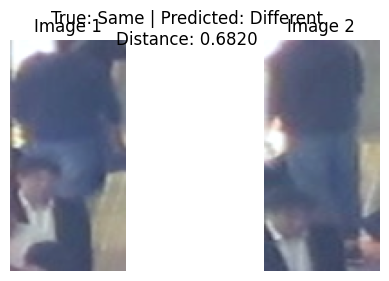

In [ ]:
# Get a random sample from the DataLoader
img1, img2, label = next(iter(reid_loader))

# Take first sample in batch
img1_sample = img1[0]
img2_sample = img2[0]
true_label = label[0].item()

# Predict similarity
distance, pred_label = predict_similarity(model, img1_sample, img2_sample)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes[0].imshow(img1_sample.permute(1,2,0).cpu().numpy() * 0.229 + 0.485)
axes[0].set_title('Image 1')
axes[1].imshow(img2_sample.permute(1,2,0).cpu().numpy() * 0.229 + 0.485)
axes[1].set_title('Image 2')
for ax in axes:
    ax.axis('off')
plt.suptitle(f"True: {'Same' if true_label==1 else 'Different'} | Predicted: {'Same' if pred_label==1 else 'Different'}\nDistance: {distance:.4f}")
plt.show()


#Extract Bonus Video

In [ ]:
import cv2
import os

video_path = "/content/test_video.mp4"  # update after upload
output_dir = "/content/test_frames"
os.makedirs(output_dir, exist_ok=True)

cap = cv2.VideoCapture(video_path)
frame_num = 0

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break
    cv2.imwrite(os.path.join(output_dir, f"{frame_num:06d}.jpg"), frame)
    frame_num += 1

cap.release()
print(f"✅ Extracted {frame_num} frames.")


✅ Extracted 0 frames.


# Generated Video

In [ ]:
class SimpleTracker:
    def __init__(self, reid_model, threshold=0.5, device='cuda'):
        self.reid_model = reid_model
        self.tracks = {}  # track_id: embedding
        self.next_id = 0
        self.threshold = threshold
        self.device = device

    def update(self, crops):
        '''
        crops: list of PIL cropped person images
        returns: list of assigned track_ids
        '''
        track_ids = []

        for crop in crops:
            # Preprocess crop
            crop = self.preprocess(crop)
            crop = crop.unsqueeze(0).to(self.device)

            # Generate embedding
            with torch.no_grad():
                emb = self.reid_model.forward_once(crop)  # only one branch

            assigned = False
            best_dist = float('inf')
            best_id = None

            # Compare to existing tracks
            for track_id, track_emb in self.tracks.items():
                dist = F.pairwise_distance(emb, track_emb).item()
                if dist < best_dist and dist < self.threshold:
                    best_dist = dist
                    best_id = track_id

            if best_id is not None:
                track_ids.append(best_id)
                self.tracks[best_id] = emb  # Update track embedding
            else:
                # New track
                track_ids.append(self.next_id)
                self.tracks[self.next_id] = emb
                self.next_id += 1

        return track_ids

    def preprocess(self, image):
        transform = T.Compose([
            T.Resize((128, 64)),
            T.ToTensor(),
            T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])
        return transform(image)


In [ ]:
# Detection Model: Faster R-CNN
detector_model = get_frcnn_model(num_classes=2)
detector_model.load_state_dict(torch.load('frcnn.pth', map_location=device))
detector_model.to(device)
detector_model.eval()

# ReID Model: SiameseReID
reid_model = SiameseReID().to(device)
reid_model.load_state_dict(torch.load('/content/models/triplet_reid_epoch18.pth', map_location=device))
reid_model.eval()

# Initialize the Tracker
tracker = SimpleTracker(reid_model=reid_model, threshold=0.5, device=device)


In [ ]:
transform = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225])
])


In [ ]:
output_path = './output_reid_video.avi'  # or .mp4
fps = 10

sample_frame = cv2.imread('./MOT16/train/MOT16-02/img1/000001.jpg')
height, width, _ = sample_frame.shape

fourcc = cv2.VideoWriter_fourcc(*'XVID')  # or 'mp4v'
out_video = cv2.VideoWriter(output_path, fourcc, fps, (width, height))


In [ ]:
img_dir = './MOT16/train/MOT16-02/img1'
frame_files = sorted(os.listdir(img_dir))

for frame_file in tqdm(frame_files):
    frame_path = os.path.join(img_dir, frame_file)
    frame = Image.open(frame_path).convert("RGB")
    orig_frame = cv2.cvtColor(np.array(frame), cv2.COLOR_RGB2BGR)

    # Detection Step (call detector_model)
    img_tensor = transform(frame).unsqueeze(0).to(device)
    with torch.no_grad():
        prediction = detector_model(img_tensor)

    boxes = prediction[0]['boxes'].cpu()
    scores = prediction[0]['scores'].cpu()

    keep = scores > 0.7
    boxes = boxes[keep]

    crops = []
    for box in boxes:
        x1, y1, x2, y2 = map(int, box.tolist())
        crop = frame.crop((x1, y1, x2, y2))
        crops.append(crop)

    # Update tracker
    track_ids = tracker.update(crops)

    # Draw boxes + IDs
    for box, track_id in zip(boxes, track_ids):
        x1, y1, x2, y2 = map(int, box.tolist())
        cv2.rectangle(orig_frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(orig_frame, f"ID {track_id}", (x1, y1-10), cv2.FONT_HERSHEY_SIMPLEX,
                    0.5, (0, 255, 0), 2)

    # Save frame to video
    out_video.write(orig_frame)

out_video.release()
print("✅ Video generation complete!")


#Backup

In [ ]:
'''
save_dir = "/content/drive/MyDrive/siamese_models"
os.makedirs(save_dir, exist_ok=True)
